In [1]:
import sys, os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, BatchNormalization, Flatten, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
if BASE_DIR not in sys.path:
    sys.path.append(BASE_DIR)

from data_processing import MelDataManager

data_folder = "../../data/genres_original"
classes = ['blues', 'classical', 'country', 'disco', 'hiphop','jazz', 'metal', 'pop', 'reggae', 'rock']

2026-01-10 19:19:57.147420: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# # --- GPU + Mixed Precision Setup (start cell) ---
from tensorflow.keras import mixed_precision

# Hide unnecessary info
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# Check if GPU is loaded
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU detected: {gpus[0].name}")
else:
    print("GPU NOT detected — TensorFlow will run on CPU")

mixed_precision.set_global_policy("mixed_float16")
print("Mixed precision enabled (mixed_float16)")

print(f"TensorFlow version: {tf.__version__}")
print(f"Compute dtype: {mixed_precision.global_policy().compute_dtype}")
print(f"Variable dtype: {mixed_precision.global_policy().variable_dtype}")

GPU detected: /physical_device:GPU:0
Mixed precision enabled (mixed_float16)
TensorFlow version: 2.20.0
Compute dtype: float16
Variable dtype: float32


In [3]:
mgr = MelDataManager(
    data_folder=data_folder,
    classes=classes,
    cache_path="../../data/processed/melspec_cache.npz",
    target_shape=(150, 150),
    chunk_duration=4,
    overlap_duration=2,
)

data, labels = mgr.load_or_build_cache()
print(f"Data shape: {data.shape}")
print(f"Labels shape (before one-hot): {labels.shape}")

Loaded cached data from ../../data/processed/melspec_cache.npz
Data shape: (14975, 150, 150, 1)
Labels shape (before one-hot): (14975,)


In [4]:
labels = mgr.one_hot()
print(f"Labels shape (one-hot): {labels.shape}")

Labels shape (one-hot): (14975, 10)


In [5]:
X_train, X_test, Y_train, Y_test = mgr.split(test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"Y_test shape: {Y_test.shape}")

X_train shape: (11980, 150, 150, 1)
X_test shape: (2995, 150, 150, 1)
Y_train shape: (11980, 10)
Y_test shape: (2995, 10)


In [6]:
# Zdefiniuj kluczowe stałe
INPUT_SHAPE = (150, 150, 1) # Wymiar Twoich spektrogramów (Wysokość, Szerokość, Kanały)
NUM_CLASSES = 10           # Liczba gatunków muzycznych

# Użyj modelu Sequential
CNN_2 = Sequential([
    # Warstwa wejściowa (Input Layer)
    Input(shape=INPUT_SHAPE),

    # Blok 1: Conv1 + Pool1 + BatchNorm1
    # Conv1: 32 filtry, rozmiar jądra 3x3, padding='same'
    Conv2D(filters=32, kernel_size=(3, 3), strides=(1, 1), padding='same', activation='relu', name='conv1'),
    # BatchNorm1: Normalizacja wsadowa (PyTorch 'bn1')
    BatchNormalization(name='bn1'),
    # Pool1: Redukcja wymiaru 2x2, stride=2
    MaxPool2D(pool_size=(2, 2), strides=(2, 2), name='pool1'),

    # Blok 2: Conv2 + Pool2 + BatchNorm2
    # Conv2: 64 filtry, rozmiar jądra 3x3, padding='same'
    Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), padding='same', activation='relu', name='conv2'),
    # BatchNorm2: Normalizacja wsadowa (PyTorch 'bn2')
    BatchNormalization(name='bn2'),
    # Pool2: Redukcja wymiaru 2x2, stride=2
    MaxPool2D(pool_size=(2, 2), strides=(2, 2), name='pool2'),

    # Przekształcanie do wektora dla warstw gęstych
    Flatten(name='flatten'),

    # Warstwy Gęste (Fully Connected)
    # FC1: 128 jednostek (PyTorch 'fc1')
    Dense(units=128, activation='relu', name='fc1'),
    # Dropout: Prawdopodobieństwo 0.5 (PyTorch 'dropout1')
    Dropout(rate=0.5, name='dropout1'),

    # FC2 (Wyjściowa): 10 jednostek, 'softmax' do klasyfikacji (PyTorch 'fc2')
    Dense(units=NUM_CLASSES, activation='softmax', name='fc2')
])

# Wyświetl podsumowanie modelu
CNN_2.summary()

I0000 00:00:1768069283.344493   13065 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3536 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 150, 150, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 75, 75, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 87616)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │    11,214,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,235,466 (42.86 MB)

 Trainable params: 11,235,274 (42.86 MB)

 Non-trainable params: 192 (768.00 B)

In [7]:
CNN_2.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
if 'X_train' in locals() and 'Y_train' in locals():
    print("\nRozpoczynanie treningu (30 epok, batch_size=32)...")
    training_history = CNN_2.fit(
        X_train,
        Y_train,
        epochs=30,
        batch_size=32,
        validation_data=(X_test, Y_test)
    )
    print("\nTrening zakończony!")
else:
    print("\n--- UWAGA: Dane treningowe (X_train, Y_train) nie są dostępne. ---")
    print("Nie można uruchomić model.fit. Upewnij się, że wykonałeś preprocessing i podział danych (komórki 1-8).")


Rozpoczynanie treningu (30 epok, batch_size=32)...


2026-01-10 19:21:32.077462: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 1078200000 exceeds 10% of free system memory.
2026-01-10 19:21:34.436167: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 1078200000 exceeds 10% of free system memory.


Epoch 1/30


2026-01-10 19:21:37.032369: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f2270007a20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-10 19:21:37.032437: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2026-01-10 19:21:37.835364: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-10 19:21:39.025164: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91700
2026-01-10 19:21:39.648061: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


  5/375 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.1151 - loss: 4.0041 

I0000 00:00:1768069327.280556   13532 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.1952 - loss: 2.8136

2026-01-10 19:22:27.826753: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 269550000 exceeds 10% of free system memory.
2026-01-10 19:22:28.681507: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 269550000 exceeds 10% of free system memory.


375/375 ━━━━━━━━━━━━━━━━━━━━ 60s 74ms/step - accuracy: 0.2285 - loss: 2.3124 - val_accuracy: 0.2227 - val_loss: 2.0475
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.3390 - loss: 1.8960 - val_accuracy: 0.4077 - val_loss: 1.6934
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.4069 - loss: 1.6951 - val_accuracy: 0.5513 - val_loss: 1.3988
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.4635 - loss: 1.4912 - val_accuracy: 0.5482 - val_loss: 1.3478
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.5179 - loss: 1.3552 - val_accuracy: 0.6220 - val_loss: 1.1627
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.5705 - loss: 1.2019 - val_accuracy: 0.6477 - val_loss: 1.0651
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.5919 - loss: 1.1183 - val_accuracy: 0.6738 - val_loss: 1.0087
Epoch 8/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.6375 - loss: 1.0052 - val_accuracy: 0.68

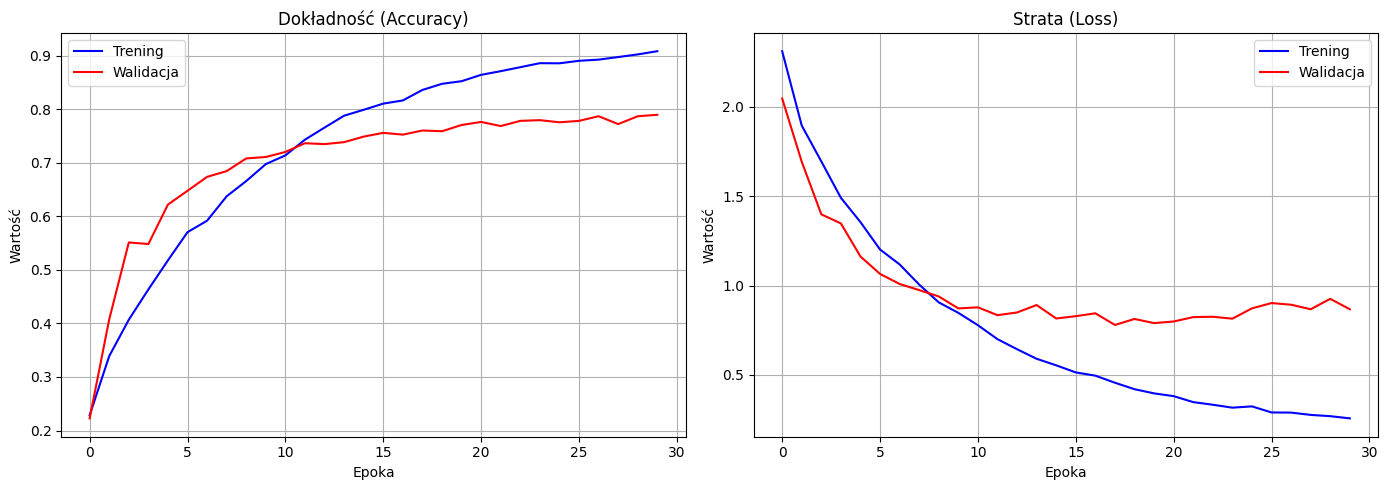

In [9]:
acc = training_history.history['accuracy']
val_acc = training_history.history['val_accuracy']
loss = training_history.history['loss']
val_loss = training_history.history['val_loss']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(acc, label='Trening', color='blue')
ax1.plot(val_acc, label='Walidacja', color='red')
ax1.set_title('Dokładność (Accuracy)')
ax1.set_xlabel('Epoka')
ax1.set_ylabel('Wartość')
ax1.legend()
ax1.grid(True)

ax2.plot(loss, label='Trening', color='blue')
ax2.plot(val_loss, label='Walidacja', color='red')
ax2.set_title('Strata (Loss)')
ax2.set_xlabel('Epoka')
ax2.set_ylabel('Wartość')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [11]:
CNN_2.save('../models/CNN_2.keras')
print("Model zapisany jako: ../models/CNN_2.keras")

Model zapisany jako: ../models/CNN_2.keras
